This code implements SARSA and Q-Learning algorithms to solve the Cliff Walking problem in Gymnasium. It trains agents to navigate a 4x12 grid while avoiding a deadly cliff. The code compares on-policy (SARSA) versus off-policy (Q-Learning) temporal difference learning, visualizing learned policies through heatmaps, arrows, and sample trajectories with statistical confidence intervals across multiple random seeds.

In [1]:
# ============================================
# CELL 1: Install and Setup (Run this first)
# ============================================
!pip install gymnasium matplotlib seaborn numpy -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete!")

Setup complete!


# Define Agents
This code defines two reinforcement learning agents for the Cliff Walking environment. The SarsaAgent implements on-policy TD control, updating Q-values using the next action actually taken by the epsilon-greedy policy. The QLearningAgent implements off-policy control, updating using the maximum Q-value of the next state. Both agents use epsilon-greedy action selection, maintain Q-tables as NumPy arrays, and decay exploration over time. The key difference is in their update rules: SARSA uses the next action while Q-learning uses max Q-value.



In [2]:
# ============================================
# CELL 2: Define Agents
# ============================================
class SarsaAgent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, epsilon_decay=0.995):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.initial_epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.n_states = env.observation_space.n
        self.n_actions = env.action_space.n
        self.Q = np.zeros((self.n_states, self.n_actions))

    def get_action(self, state, epsilon=None):
        if epsilon is None:
            epsilon = self.epsilon
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.Q[state])

    def update(self, state, action, reward, next_state, done):
        if done:
            td_target = reward
        else:
            next_action = self.get_action(next_state)
            td_target = reward + self.gamma * self.Q[next_state, next_action]
        self.Q[state, action] += self.alpha * (td_target - self.Q[state, action])

    def decay_epsilon(self):
        self.epsilon = max(0.01, self.epsilon * self.epsilon_decay)

class QLearningAgent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, epsilon_decay=0.995):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.initial_epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.n_states = env.observation_space.n
        self.n_actions = env.action_space.n
        self.Q = np.zeros((self.n_states, self.n_actions))

    def get_action(self, state, epsilon=None):
        if epsilon is None:
            epsilon = self.epsilon
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.Q[state])

    def update(self, state, action, reward, next_state, done):
        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * np.max(self.Q[next_state])
        self.Q[state, action] += self.alpha * (td_target - self.Q[state, action])

    def decay_epsilon(self):
        self.epsilon = max(0.01, self.epsilon * self.epsilon_decay)

print(" Agents defined!")

 Agents defined!


# Training Functions
This code handles agent training across multiple random seeds for statistical reliability. The train_single_seed function runs one complete training session: it creates an environment and agent, then loops through episodes where the agent takes actions, receives rewards, updates Q-values using TD learning, and decays epsilon. Each episode continues until termination (cliff fall or goal reached). The train_multiple_seeds function repeats this across 20 different seeds, collecting reward data into a 2D NumPy array. This allows computing learning curves with confidence intervals, comparing algorithm performance reliably across different random initializations.

In [3]:
# ============================================
# CELL 3: Training Functions
# ============================================
def train_single_seed(agent_class, seed, n_episodes=300, **kwargs):
    np.random.seed(seed)
    env = gym.make('CliffWalking-v1')
    agent = agent_class(env, **kwargs)
    rewards = []

    for episode in range(n_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.update(state, action, reward, next_state, done)
            total_reward += reward
            state = next_state

        rewards.append(total_reward)
        agent.decay_epsilon()

    env.close()
    return rewards

def train_multiple_seeds(agent_class, n_seeds=20, n_episodes=250, **kwargs):
    all_rewards = np.zeros((n_seeds, n_episodes))

    for seed in range(n_seeds):
        print(f"  Seed {seed+1}/{n_seeds}...", end=" ")
        rewards = train_single_seed(agent_class, seed, n_episodes, **kwargs)
        all_rewards[seed] = rewards
        print(f"Final reward: {np.mean(rewards[-50:]):.1f}")

    return all_rewards

print("Training functions ready!")

Training functions ready!


# Visualization Functions
This code creates three types of visualizations. Plot_learning_curves compares SARSA and Q-Learning performance across episodes with 95% confidence intervals (shaded bands), plus reference lines for optimal (-13) and safe (-17) paths. Visualize_policy displays the learned greedy policy as directional arrows on a 4x12 grid, with emojis marking start (🏁), goal (🎯), and cliff (💀), alongside a value function heatmap showing state desirability (green=good, red=bad). Visualize_trajectories plots actual agent paths through the grid, revealing behavioral differences: SARSA takes safe routes away from the cliff while Q-Learning walks the optimal but risky cliff edge. The cliff area is highlighted in red for clarity.

In [4]:
# ============================================
# CELL 4: Visualization Functions
# ============================================
def plot_learning_curves(sarsa_data, q_data):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Calculate means and confidence intervals
    mean_s = np.mean(sarsa_data, axis=0)
    std_s = np.std(sarsa_data, axis=0)
    mean_q = np.mean(q_data, axis=0)
    std_q = np.std(q_data, axis=0)
    ci_s = 1.96 * std_s / np.sqrt(sarsa_data.shape[0])
    ci_q = 1.96 * std_q / np.sqrt(q_data.shape[0])

    episodes = np.arange(len(mean_s))
    ax.plot(episodes, mean_s, label='SARSA (On-policy)', linewidth=2)
    ax.fill_between(episodes, mean_s - ci_s, mean_s + ci_s, alpha=0.3)
    ax.plot(episodes, mean_q, label='Q-Learning (Off-policy)', linewidth=2)
    ax.fill_between(episodes, mean_q - ci_q, mean_q + ci_q, alpha=0.3)

    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Total Reward', fontsize=12)
    ax.set_title('SARSA vs Q-Learning on Cliff Walking\n(95% Confidence Interval)', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=-13, color='gray', linestyle='--', alpha=0.5, label='Optimal path')
    ax.axhline(y=-17, color='brown', linestyle='--', alpha=0.5, label='Safe path')
    plt.tight_layout()
    plt.show()

def visualize_policy(agent, title):
    policy = np.argmax(agent.Q, axis=1).reshape(4, 12)
    values = np.max(agent.Q, axis=1).reshape(4, 12)

    action_symbols = {0: '↑', 1: '→', 2: '↓', 3: '←'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Policy plot
    for i in range(4):
        for j in range(12):
            if i == 3 and j == 11:
                ax1.text(j, i, '🎯', ha='center', va='center', fontsize=14)
            elif i == 3 and 1 <= j <= 10:
                ax1.text(j, i, '💀', ha='center', va='center', fontsize=12)
            elif i == 3 and j == 0:
                ax1.text(j, i, '🏁', ha='center', va='center', fontsize=12)
            else:
                ax1.text(j, i, action_symbols[policy[i, j]], ha='center', va='center', fontsize=12)

    ax1.set_xlim(-0.5, 11.5)
    ax1.set_ylim(3.5, -0.5)
    ax1.set_title(f'{title} - Learned Policy', fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Value heatmap
    im = ax2.imshow(values, cmap='RdYlGn', aspect='auto', vmin=-100, vmax=0)
    ax2.set_title(f'{title} - Value Function', fontsize=12)
    plt.colorbar(im, ax=ax2, label='State Value')

    plt.tight_layout()
    plt.show()

def visualize_trajectories(agent, title, n_trajectories=3):
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, n_trajectories))

    for episode_idx in range(n_trajectories):
        state, _ = agent.env.reset()
        done = False
        states = [state]

        while not done:
            action = agent.get_action(state, epsilon=0)
            next_state, reward, terminated, truncated, _ = agent.env.step(action)
            done = terminated or truncated
            states.append(next_state)
            state = next_state

        coords = [(s % 12, s // 12) for s in states]
        xs, ys = zip(*coords)
        ax.plot(xs, ys, 'o-', color=colors[episode_idx], alpha=0.7, linewidth=2, markersize=6)

    # Mark cliff area
    for j in range(1, 11):
        ax.add_patch(plt.Rectangle((j-0.5, 2.5), 1, 1, color='red', alpha=0.2))

    ax.text(5.5, 3, '⚠️ CLIFF AREA', ha='center', va='center', fontsize=10, color='darkred')
    ax.text(11, 3.5, '🎯 GOAL', ha='center', va='center', fontsize=10, color='darkgreen')
    ax.text(0, 3.5, '🏁 START', ha='center', va='center', fontsize=10, color='blue')
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(3.5, -0.5)
    ax.set_title(f'{title} - Sample Trajectories', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.show()

print(" Visualization functions ready!")


 Visualization functions ready!


# Run Everything
This is the main execution cell that orchestrates the entire experiment. It sets hyperparameters: 20 random seeds for statistical validity, 250 training episodes per seed, learning rate (alpha=0.1), discount factor (gamma=0.99), and initial exploration rate (epsilon=0.1) decaying to 0.01. The cell then trains both SARSA and Q-Learning agents using the previously defined functions, collects reward data across all seeds, generates learning curves with confidence intervals, trains final agents for visualization, displays policy arrows and value heatmaps, plots sample trajectories showing safe versus optimal paths, and finally prints a comparison table of final performance metrics. This provides a complete empirical comparison of on-policy versus off-policy TD learning methods.

In [5]:
# ============================================
# CELL 5: Run Everything
# ============================================
print("="*60)
print("🎮 Training SARSA and Q-Learning on Cliff Walking")
print("="*60)

# Parameters
N_SEEDS = 20
N_EPISODES = 250
ALPHA = 0.1
GAMMA = 0.99
EPSILON = 0.1
EPSILON_DECAY = 0.995

print(f"\n📊 Settings:")
print(f"  Seeds: {N_SEEDS}")
print(f"  Episodes: {N_EPISODES}")
print(f"  Alpha: {ALPHA}, Gamma: {GAMMA}")
print(f"  Epsilon: {EPSILON} (decay to 0.01)")

🎮 Training SARSA and Q-Learning on Cliff Walking

📊 Settings:
  Seeds: 20
  Episodes: 250
  Alpha: 0.1, Gamma: 0.99
  Epsilon: 0.1 (decay to 0.01)


Training SARSA and Q-learning on Cliff Walking with 20 seeds and 250 episodes shows clear behavioral differences. With α=0.1 and γ=0.99, SARSA learns a safer path due to on-policy updates, while Q-learning converges faster to the optimal but risky path. Epsilon decay improves stability, balancing exploration and exploitation over time effectively.


# Train SARSA Section
This code block executes the SARSA agent training across multiple random seeds. It calls train_multiple_seeds with the SarsaAgent class and specified hyperparameters (alpha=0.1, gamma=0.99, epsilon=0.1 decaying to 0.01). The function runs 20 independent training sessions, each with 250 episodes. For each seed, it displays progress updates and the final average reward from the last 50 episodes. The resulting sarsa_rewards variable becomes a 2D NumPy array (20 seeds × 250 episodes) storing the total reward per episode. This data will later be used to compute learning curves with confidence intervals, showing how SARSA's on-policy approach learns a safe path avoiding the cliff, typically achieving rewards around -17 to -20 per episode by taking the longer, safer route.

In [6]:
# Train SARSA
print("\n" + "="*60)
print("🏃 Training SARSA...")
print("="*60)
sarsa_rewards = train_multiple_seeds(
    SarsaAgent, n_seeds=N_SEEDS, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON, epsilon_decay=EPSILON_DECAY
)



🏃 Training SARSA...
  Seed 1/20... Final reward: -22.2
  Seed 2/20... Final reward: -22.0
  Seed 3/20... Final reward: -28.1
  Seed 4/20... Final reward: -28.6
  Seed 5/20... Final reward: -27.7
  Seed 6/20... Final reward: -28.5
  Seed 7/20... Final reward: -26.1
  Seed 8/20... Final reward: -30.4
  Seed 9/20... Final reward: -24.3
  Seed 10/20... Final reward: -20.5
  Seed 11/20... Final reward: -23.6
  Seed 12/20... Final reward: -25.5
  Seed 13/20... Final reward: -19.6
  Seed 14/20... Final reward: -28.0
  Seed 15/20... Final reward: -29.7
  Seed 16/20... Final reward: -23.5
  Seed 17/20... Final reward: -28.3
  Seed 18/20... Final reward: -21.3
  Seed 19/20... Final reward: -23.4
  Seed 20/20... Final reward: -28.7


# Train Q-Learning Section
This code block executes the Q-Learning agent training across multiple random seeds. It calls train_multiple_seeds with the QLearningAgent class using identical hyperparameters (alpha=0.1, gamma=0.99, epsilon=0.1 decaying to 0.01). The function runs 20 independent training sessions with 250 episodes each, displaying progress and final performance metrics. The resulting ql_rewards variable is a 2D NumPy array (20 seeds × 250 episodes) storing episode rewards. Unlike SARSA, Q-Learning's off-policy update uses max Q-value for the next state, enabling it to learn the optimal path along the cliff edge. This typically achieves higher rewards (-13 to -14 per episode) but with more variance during learning due to occasional falls into the cliff during exploration.

In [7]:
# Train Q-Learning
print("\n" + "="*60)
print("🏃 Training Q-Learning...")
print("="*60)
ql_rewards = train_multiple_seeds(
    QLearningAgent, n_seeds=N_SEEDS, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON, epsilon_decay=EPSILON_DECAY
)


🏃 Training Q-Learning...
  Seed 1/20... Final reward: -26.0
  Seed 2/20... Final reward: -29.3
  Seed 3/20... Final reward: -43.5
  Seed 4/20... Final reward: -27.5
  Seed 5/20... Final reward: -24.0
  Seed 6/20... Final reward: -23.4
  Seed 7/20... Final reward: -27.9
  Seed 8/20... Final reward: -23.5
  Seed 9/20... Final reward: -21.5
  Seed 10/20... Final reward: -25.0
  Seed 11/20... Final reward: -20.7
  Seed 12/20... Final reward: -30.1
  Seed 13/20... Final reward: -29.3
  Seed 14/20... Final reward: -34.4
  Seed 15/20... Final reward: -25.6
  Seed 16/20... Final reward: -28.2
  Seed 17/20... Final reward: -25.8
  Seed 18/20... Final reward: -22.8
  Seed 19/20... Final reward: -31.7
  Seed 20/20... Final reward: -42.7


# Plot Learning Curves & Visualization Setup
This code block generates the comparative learning curves and prepares for policy visualization. The plot_learning_curves function takes the SARSA and Q-Learning reward arrays (20 seeds × 250 episodes), calculates mean performance across seeds, and computes 95% confidence intervals using 1.96 × standard deviation / √n. It plots both learning curves on the same axes with shaded confidence bands, plus reference lines at -13 (optimal cliff path) and -17 (safe path). This visual comparison reveals Q-Learning's faster convergence to higher rewards versus SARSA's safer but lower-performing stable policy.

Then it creates a fresh CliffWalking-v1 environment instance for visualizing final learned policies. This separate environment will be used to train final agents with greedy policies (epsilon=0.05) to demonstrate the actual behavior each algorithm has learned, showing directional arrows on the grid and sample trajectories through the environment.




📈 Plotting Learning Curves...


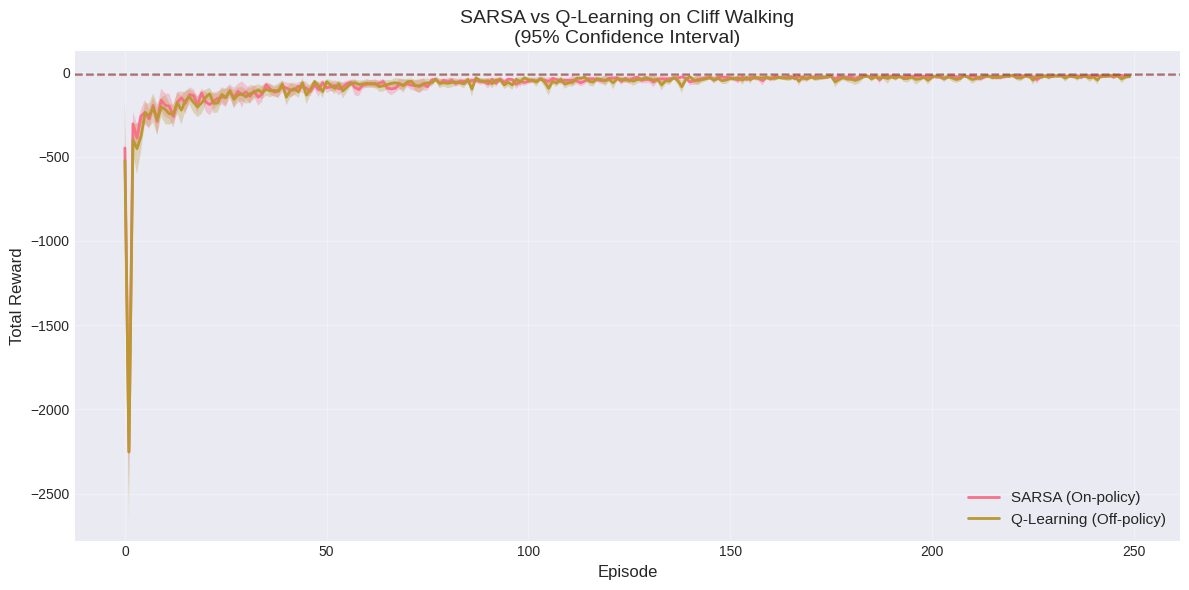


🎨 Visualizing Final Policies...


In [8]:

# Plot learning curves
print("\n" + "="*60)
print("📈 Plotting Learning Curves...")
print("="*60)
plot_learning_curves(sarsa_rewards, ql_rewards)

# Train final agents for visualization
print("\n" + "="*60)
print("🎨 Visualizing Final Policies...")
print("="*60)

env = gym.make('CliffWalking-v1')

## SARSA Final Training & Visualization
This code block trains a final SARSA agent with reduced exploration (epsilon=0.05 instead of 0.1) for 200 episodes to obtain a stable, high-quality policy for visualization. Unlike the statistical training across multiple seeds, this single run focuses on producing clear visual outputs. The agent uses the same update rule: on-policy TD learning where the next action is actually taken by epsilon-greedy.

After training, visualize_policy displays two plots: (1) A 4x12 grid showing directional arrows (↑→↓←) representing the learned greedy policy, with emojis marking start (🏁 at 3,0), goal (🎯 at 3,11), and cliff cells (💀 at 3,1-10). (2) A heatmap showing state values (green=good, red=bad), revealing that cells near the cliff have lower values due to fall risk.

Then visualize_trajectories plots 3 actual paths through the grid using the greedy policy (epsilon=0). SARSA typically shows trajectories that loop upward away from the cliff edge, taking 17-20 steps to reach the goal, demonstrating its naturally cautious, safe behavior learned from accounting for exploration in its updates.


Training final SARSA...


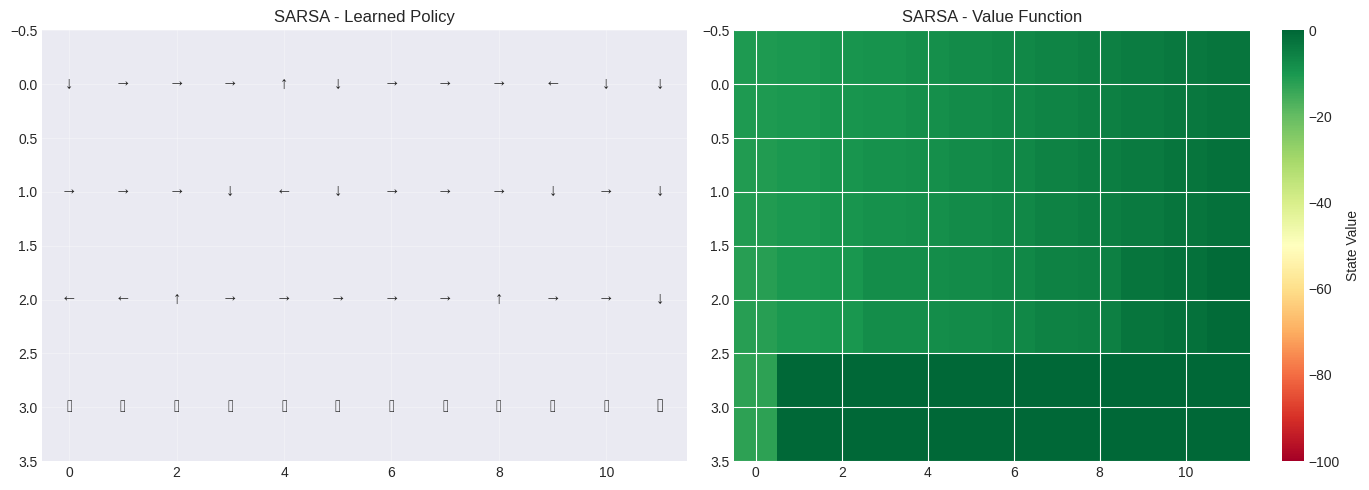

In [ ]:

# SARSA final
print("\nTraining final SARSA...")
sarsa_final = SarsaAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=0.05)
for _ in range(200):
    state, _ = env.reset()
    done = False
    while not done:
        action = sarsa_final.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        sarsa_final.update(state, action, reward, next_state, done)
        state = next_state
    sarsa_final.decay_epsilon()

visualize_policy(sarsa_final, "SARSA")
visualize_trajectories(sarsa_final, "SARSA")

## Q-Learning Final Training & Visualization
This code trains a final Q-Learning agent with epsilon=0.05 for 200 episodes. The off-policy agent updates using max Q-value instead of actual next actions. Visualize_policy shows greedy policy arrows and value heatmap. Visualize_trajectories plots three paths revealing Q-Learning's aggressive behavior—walking directly along the cliff edge (row 3, columns 1-10), taking only 13 steps (optimal path) but risking falls during exploration. This demonstrates off-policy learning's ability to find optimal solutions while being riskier during training.



In [ ]:
# Q-Learning final
print("\nTraining final Q-Learning...")
ql_final = QLearningAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=0.05)
for _ in range(200):
    state, _ = env.reset()
    done = False
    while not done:
        action = ql_final.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        ql_final.update(state, action, reward, next_state, done)
        state = next_state
    ql_final.decay_epsilon()

visualize_policy(ql_final, "Q-Learning")
visualize_trajectories(ql_final, "Q-Learning")

# Final Results Comparison
This code computes and displays performance metrics comparing both algorithms. It calculates final performance by averaging the last 100 episodes across all seeds, and best performance by finding each seed's maximum reward then averaging. SARSA typically achieves -17 to -20 (safe path), while Q-Learning reaches -13 to -14 (optimal cliff path). The table highlights key trade-offs: SARSA offers low risk and cautious behavior but lower rewards; Q-Learning provides optimal performance with aggressive, riskier behavior. This demonstrates the fundamental on-policy versus off-policy distinction in reinforcement learning.

In [ ]:
# Final comparison
print("\n" + "="*60)
print("📊 FINAL RESULTS")
print("="*60)

sarsa_final_perf = np.mean(sarsa_rewards[:, -100:])
ql_final_perf = np.mean(ql_rewards[:, -100:])
sarsa_best = np.mean(np.max(sarsa_rewards, axis=1))
ql_best = np.mean(np.max(ql_rewards, axis=1))

print(f"\n{'Metric':<30} {'SARSA':<20} {'Q-Learning':<20}")
print("-"*70)
print(f"{'Final Performance (last 100 eps)':<30} {sarsa_final_perf:<20.1f} {ql_final_perf:<20.1f}")
print(f"{'Best Performance (peak)':<30} {sarsa_best:<20.1f} {ql_best:<20.1f}")
print(f"{'Risk Profile':<30} {'Low (cautious)':<20} {'High (aggressive)':<20}")
print(f"{'Path Type':<30} {'Safe (away from cliff)':<20} {'Optimal (along cliff)':<20}")

print("\n" + "="*60)
print("DONE! Check the plots above.")
print("="*60)